# From-Scratch ResNet18 for Fine-Grained Species Classification

**Dataset:** fixed 500-class subset of iNaturalist 2021  
**Training split:** 20,000 images  
**Validation split:** 5,000 images  
**Test split:** 5,000 images  
**Model:** ResNet18 with random initialization (`weights=None`)  
**Evaluation:** Top-1 accuracy, Top-5 accuracy, macro precision, macro recall, and macro F1  
**Ablation:** data augmentation versus no data augmentation  
**Robustness:** Gaussian noise, Gaussian blur, brightness, contrast, and JPEG compression

## 1. Environment and configuration

In [1]:
from __future__ import annotations

import json
import os
import random
import sys
import time
from contextlib import nullcontext
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import resnet18

cwd = Path.cwd().resolve()

if (cwd / "data" / "splits").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data" / "splits").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Run this notebook from the project root or place it in the project's notebooks directory."
    )

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)

Project root: /Users/joy/Downloads/COMP9517_Project
Python: 3.14.3
PyTorch: 2.13.0


In [2]:
@dataclass(frozen=True)
class Config:
    seed: int = 9517
    num_classes: int = 500
    image_size: int = 224
    batch_size: int = 16
    epochs: int = 30
    learning_rate: float = 3e-4
    weight_decay: float = 1e-4
    patience: int = 10
    num_workers: int = 0

CFG = Config()

def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = get_device()
AMP_ENABLED = DEVICE.type == "cuda"

print(asdict(CFG))
print("Device:", DEVICE)
print("Mixed precision:", AMP_ENABLED)

{'seed': 9517, 'num_classes': 500, 'image_size': 224, 'batch_size': 16, 'epochs': 30, 'learning_rate': 0.0003, 'weight_decay': 0.0001, 'patience': 10, 'num_workers': 0}
Device: mps
Mixed precision: False


In [3]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(CFG.seed)

## 2. Dataset validation

In [4]:
required_paths = [
    Path("data/raw/train_mini"),
    Path("data/raw/val"),
    Path("data/splits/train_paths.csv"),
    Path("data/splits/val_paths.csv"),
    Path("data/splits/test_paths.csv"),
    Path("src/degradations.py"),
]

missing = [str(path) for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required files:\n" + "\n".join(missing))

split_frames = {}

for split in ("train", "val", "test"):
    frame = pd.read_csv(f"data/splits/{split}_paths.csv")
    split_frames[split] = frame

    print(
        f"{split:5s} | images={len(frame):5d} | "
        f"classes={frame['class_idx'].nunique():3d} | "
        f"class range=({frame['class_idx'].min()}, {frame['class_idx'].max()})"
    )

assert len(split_frames["train"]) == 20_000
assert len(split_frames["val"]) == 5_000
assert len(split_frames["test"]) == 5_000
assert all(frame["class_idx"].nunique() == 500 for frame in split_frames.values())

train | images=20000 | classes=500 | class range=(0, 499)
val   | images= 5000 | classes=500 | class range=(0, 499)
test  | images= 5000 | classes=500 | class range=(0, 499)


Sample path: data/raw/train_mini/00044_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Trichonephila_clavata/41c2ba64-5a5f-438f-9f97-f2616a4f632b.jpg
Image size: (500, 281)
Class index: 0


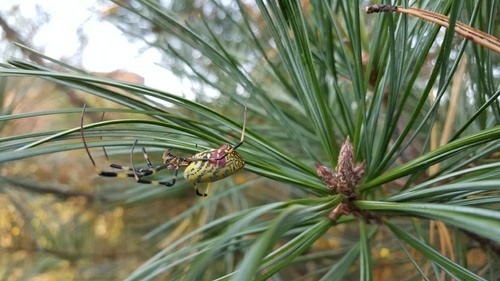

In [5]:
def resolve_image_path(raw_path: str) -> Path:
    direct = Path(str(raw_path))
    if direct.exists():
        return direct

    converted = Path(str(raw_path).replace("\\", os.sep).replace("/", os.sep))
    if converted.exists():
        return converted

    raise FileNotFoundError(f"Image not found: {raw_path}")

sample_row = split_frames["train"].iloc[0]
sample_path = resolve_image_path(sample_row["image_path"])

with Image.open(sample_path) as image_file:
    sample_image = image_file.convert("RGB")

print("Sample path:", sample_path)
print("Image size:", sample_image.size)
print("Class index:", int(sample_row["class_idx"]))
display(sample_image)

## 3. Data pipeline

In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def build_transform(split: str, augment: bool) -> transforms.Compose:
    if split == "train" and augment:
        return transforms.Compose(
            [
                transforms.RandomResizedCrop(CFG.image_size),
                transforms.RandomHorizontalFlip(),
                transforms.ColorJitter(
                    brightness=0.2,
                    contrast=0.2,
                    saturation=0.2,
                ),
                transforms.ToTensor(),
                transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            ]
        )

    return transforms.Compose(
        [
            transforms.Resize(int(CFG.image_size * 1.15)),
            transforms.CenterCrop(CFG.image_size),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]
    )


class SpeciesDataset(Dataset):
    def __init__(
        self,
        csv_path: str | Path,
        split: str,
        augment: bool = False,
    ):
        self.frame = pd.read_csv(csv_path)
        self.transform = build_transform(split, augment)

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int):
        row = self.frame.iloc[index]
        path = resolve_image_path(row["image_path"])

        with Image.open(path) as image_file:
            image = image_file.convert("RGB")

        image = self.transform(image)
        label = int(row["class_idx"])
        return image, label


def make_loader(
    csv_path: str | Path,
    split: str,
    augment: bool = False,
    shuffle: Optional[bool] = None,
) -> DataLoader:
    if shuffle is None:
        shuffle = split == "train"

    dataset = SpeciesDataset(csv_path, split, augment)

    return DataLoader(
        dataset,
        batch_size=CFG.batch_size,
        shuffle=shuffle,
        num_workers=CFG.num_workers,
        pin_memory=DEVICE.type == "cuda",
    )

In [7]:
check_loader = make_loader(
    "data/splits/train_paths.csv",
    split="train",
    augment=True,
    shuffle=False,
)

images, labels = next(iter(check_loader))

print("Batch shape:", tuple(images.shape))
print("Label shape:", tuple(labels.shape))
assert images.shape[1:] == (3, CFG.image_size, CFG.image_size)

Batch shape: (16, 3, 224, 224)
Label shape: (16,)


## 4. Model

In [8]:
def build_model(num_classes: int = CFG.num_classes) -> nn.Module:
    model = resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

model = build_model().to(DEVICE)

with torch.no_grad():
    output = model(images.to(DEVICE))

print(model)
print("Output shape:", tuple(output.shape))
assert output.shape == (images.shape[0], CFG.num_classes)

del model, output

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

## 5. Training and validation

In [9]:
def autocast_context():
    if not AMP_ENABLED:
        return nullcontext()

    try:
        return torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16,
        )
    except AttributeError:
        return torch.cuda.amp.autocast()


def create_scaler():
    try:
        return torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)


def topk_counts(logits: torch.Tensor, targets: torch.Tensor) -> tuple[int, int]:
    topk = logits.topk(k=min(5, logits.shape[1]), dim=1).indices
    top1 = int((topk[:, 0] == targets).sum().item())
    top5 = int(topk.eq(targets.view(-1, 1)).any(dim=1).sum().item())
    return top1, top5


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    scaler,
    log_every: int = 100,
) -> dict:
    model.train()

    loss_sum = 0.0
    sample_count = 0
    top1_count = 0
    top5_count = 0

    for batch_index, (images, targets) in enumerate(loader, start=1):
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast_context():
            logits = model(images)
            loss = criterion(logits, targets)

        if AMP_ENABLED:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        batch_size = targets.size(0)
        top1, top5 = topk_counts(logits.detach(), targets)

        loss_sum += float(loss.item()) * batch_size
        sample_count += batch_size
        top1_count += top1
        top5_count += top5

        if log_every and batch_index % log_every == 0:
            print(
                f"batch {batch_index:4d}/{len(loader)} | "
                f"loss={loss_sum / sample_count:.4f} | "
                f"top1={top1_count / sample_count:.4f}"
            )

    return {
        "train_loss": loss_sum / sample_count,
        "train_top1": top1_count / sample_count,
        "train_top5": top5_count / sample_count,
    }


@torch.no_grad()
def validate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
) -> dict:
    model.eval()

    loss_sum = 0.0
    sample_count = 0
    top1_count = 0
    top5_count = 0
    y_true = []
    y_pred = []

    for images, targets in loader:
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        with autocast_context():
            logits = model(images)
            loss = criterion(logits, targets)

        batch_size = targets.size(0)
        top1, top5 = topk_counts(logits, targets)

        loss_sum += float(loss.item()) * batch_size
        sample_count += batch_size
        top1_count += top1
        top5_count += top5

        y_true.extend(targets.cpu().tolist())
        y_pred.extend(logits.argmax(dim=1).cpu().tolist())

    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    return {
        "val_loss": loss_sum / sample_count,
        "val_top1": top1_count / sample_count,
        "val_top5": top5_count / sample_count,
        "val_macro_precision": float(precision),
        "val_macro_recall": float(recall),
        "val_macro_f1": float(macro_f1),
    }

In [10]:
def save_checkpoint(
    path: Path,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler,
    epoch: int,
    best_val_macro_f1: float,
    run_name: str,
    augment: bool,
) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_macro_f1": best_val_macro_f1,
            "num_classes": CFG.num_classes,
            "run_name": run_name,
            "augment": augment,
            "image_size": CFG.image_size,
            "config": asdict(CFG),
        },
        path,
    )


def safe_load(path: str | Path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=DEVICE)


def save_training_plots(log_frame: pd.DataFrame, run_name: str) -> None:
    figure_dir = Path("results/figures")
    figure_dir.mkdir(parents=True, exist_ok=True)

    plt.figure(figsize=(7, 5))
    plt.plot(log_frame["epoch"], log_frame["train_loss"], label="Train")
    plt.plot(log_frame["epoch"], log_frame["val_loss"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.title(f"{run_name}: loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(figure_dir / f"{run_name}_loss_curve.png", dpi=200)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(log_frame["epoch"], log_frame["train_top1"], label="Train Top-1")
    plt.plot(log_frame["epoch"], log_frame["val_top1"], label="Validation Top-1")
    plt.plot(log_frame["epoch"], log_frame["val_top5"], label="Validation Top-5")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{run_name}: accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(figure_dir / f"{run_name}_accuracy_curve.png", dpi=200)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(log_frame["epoch"], log_frame["val_macro_f1"])
    plt.xlabel("Epoch")
    plt.ylabel("Macro F1")
    plt.title(f"{run_name}: validation macro F1")
    plt.tight_layout()
    plt.savefig(figure_dir / f"{run_name}_macro_f1_curve.png", dpi=200)
    plt.show()

In [11]:
def run_experiment(
    run_name: str,
    augment: bool,
    epochs: int = CFG.epochs,
) -> dict:
    set_seed(CFG.seed)

    train_loader = make_loader(
        "data/splits/train_paths.csv",
        split="train",
        augment=augment,
        shuffle=True,
    )

    val_loader = make_loader(
        "data/splits/val_paths.csv",
        split="val",
        augment=False,
        shuffle=False,
    )

    model = build_model().to(DEVICE)
    criterion = nn.CrossEntropyLoss()

    optimizer = AdamW(
        model.parameters(),
        lr=CFG.learning_rate,
        weight_decay=CFG.weight_decay,
    )

    scheduler = CosineAnnealingLR(
        optimizer,
        T_max=max(epochs, 1),
        eta_min=1e-6,
    )

    scaler = create_scaler()

    best_path = Path(f"results/models/{run_name}_best.pth")
    last_path = Path(f"results/models/{run_name}_last.pth")
    log_path = Path(f"results/logs/{run_name}_training_log.csv")

    best_val_macro_f1 = -1.0
    no_improvement = 0
    records = []
    total_start = time.time()

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        print(f"\nEpoch {epoch}/{epochs}")

        train_metrics = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            scaler,
        )

        val_metrics = validate(
            model,
            val_loader,
            criterion,
        )

        current_lr = float(optimizer.param_groups[0]["lr"])
        scheduler.step()

        record = {
            "epoch": epoch,
            **train_metrics,
            **val_metrics,
            "learning_rate": current_lr,
            "epoch_time_sec": time.time() - epoch_start,
        }

        records.append(record)
        log_frame = pd.DataFrame(records)

        log_path.parent.mkdir(parents=True, exist_ok=True)
        log_frame.to_csv(log_path, index=False)

        print(
            f"train_loss={record['train_loss']:.4f} | "
            f"train_top1={record['train_top1']:.4f} | "
            f"val_loss={record['val_loss']:.4f} | "
            f"val_top1={record['val_top1']:.4f} | "
            f"val_top5={record['val_top5']:.4f} | "
            f"val_macro_f1={record['val_macro_f1']:.4f}"
        )

        if record["val_macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = record["val_macro_f1"]
            no_improvement = 0

            save_checkpoint(
                best_path,
                model,
                optimizer,
                scheduler,
                epoch,
                best_val_macro_f1,
                run_name,
                augment,
            )
        else:
            no_improvement += 1

        save_checkpoint(
            last_path,
            model,
            optimizer,
            scheduler,
            epoch,
            best_val_macro_f1,
            run_name,
            augment,
        )

        if no_improvement >= CFG.patience:
            print("Early stopping.")
            break

    save_training_plots(log_frame, run_name)

    best_row = log_frame.loc[log_frame["val_macro_f1"].idxmax()]

    summary = {
        "run_name": run_name,
        "random_initialization": True,
        "augment": augment,
        "best_epoch": int(best_row["epoch"]),
        "best_val_top1": float(best_row["val_top1"]),
        "best_val_top5": float(best_row["val_top5"]),
        "best_val_macro_f1": float(best_row["val_macro_f1"]),
        "training_time_sec": time.time() - total_start,
        "best_checkpoint": str(best_path),
    }

    summary_path = Path(f"results/logs/{run_name}_summary.json")
    summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

    return summary

## 6. Training execution

In [12]:
RUN_SMOKE_TEST = False
RUN_NO_AUGMENTATION = False
RUN_AUGMENTATION = False

if RUN_SMOKE_TEST:
    smoke_summary = run_experiment(
        run_name="scratch_smoke",
        augment=True,
        epochs=1,
    )

if RUN_NO_AUGMENTATION:
    no_aug_summary = run_experiment(
        run_name="scratch_no_aug",
        augment=False,
    )

if RUN_AUGMENTATION:
    aug_summary = run_experiment(
        run_name="scratch_aug",
        augment=True,
    )

## 7. Ablation results

In [13]:
def read_json(path: str | Path) -> dict:
    with Path(path).open("r", encoding="utf-8") as file:
        return json.load(file)

summary_files = [
    Path("results/logs/scratch_no_aug_summary.json"),
    Path("results/logs/scratch_aug_summary.json"),
]

if all(path.exists() for path in summary_files):
    rows = []

    for path in summary_files:
        summary = read_json(path)
        rows.append(
            {
                "Run": summary["run_name"],
                "Augmentation": summary["augment"],
                "Best epoch": summary["best_epoch"],
                "Validation Top-1": summary["best_val_top1"],
                "Validation Top-5": summary["best_val_top5"],
                "Validation Macro F1": summary["best_val_macro_f1"],
                "Training time (s)": summary.get(
                    "total_training_time_sec",
                    summary.get("training_time_sec"),
                ),
            }
        )

    ablation_results = pd.DataFrame(rows).sort_values(
        "Validation Macro F1",
        ascending=False,
    )

    display(
        ablation_results.style.format(
            {
                "Validation Top-1": "{:.2%}",
                "Validation Top-5": "{:.2%}",
                "Validation Macro F1": "{:.2%}",
                "Training time (s)": "{:.1f}",
            }
        )
    )
else:
    print("Ablation summaries are not available.")

,Run,Augmentation,Best epoch,Validation Top-1,Validation Top-5,Validation Macro F1,Training time (s)
1,scratch_aug,True,28,31.94%,56.74%,30.06%,10124.6
0,scratch_no_aug,False,16,21.54%,43.42%,21.42%,8584.8


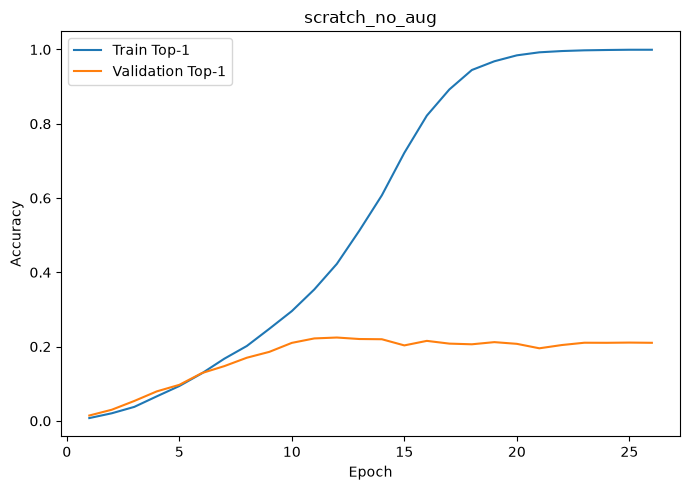

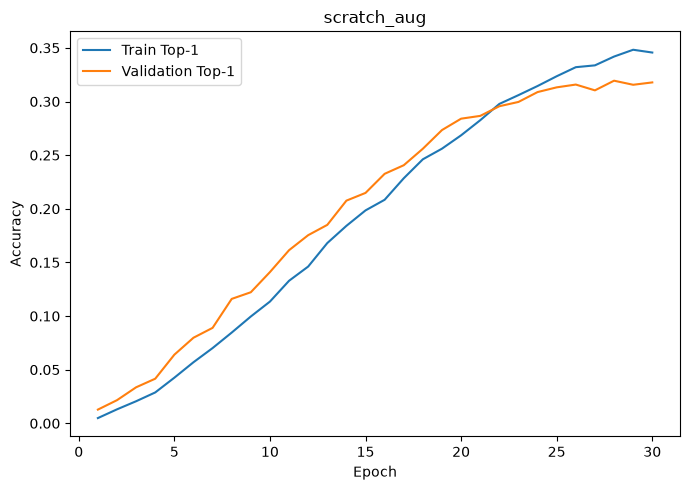

In [14]:
for run_name in ("scratch_no_aug", "scratch_aug"):
    log_path = Path(f"results/logs/{run_name}_training_log.csv")

    if not log_path.exists():
        continue

    log_frame = pd.read_csv(log_path)

    plt.figure(figsize=(7, 5))
    plt.plot(log_frame["epoch"], log_frame["train_top1"], label="Train Top-1")
    plt.plot(log_frame["epoch"], log_frame["val_top1"], label="Validation Top-1")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(run_name)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 8. Final model

In [15]:
BEST_CHECKPOINT = Path("results/models/scratch_aug_best.pth")

if BEST_CHECKPOINT.exists():
    checkpoint = safe_load(BEST_CHECKPOINT)

    final_model = build_model(
        checkpoint.get("num_classes", CFG.num_classes)
    ).to(DEVICE)

    final_model.load_state_dict(checkpoint["model_state_dict"])
    final_model.eval()

    print("Checkpoint:", BEST_CHECKPOINT)
    print("Best epoch:", checkpoint["epoch"])
    print("Run:", checkpoint["run_name"])
else:
    print("Checkpoint not found:", BEST_CHECKPOINT)

Checkpoint: results/models/scratch_aug_best.pth
Best epoch: 28
Run: scratch_aug


## 9. Clean and corrupted test prediction

In [16]:
from src.degradations import DEGRADATION_LEVELS, apply_degradation


class TestDataset(Dataset):
    def __init__(
        self,
        csv_path: str | Path,
        degradation: Optional[str] = None,
        severity=None,
    ):
        self.frame = pd.read_csv(csv_path)
        self.transform = build_transform("test", augment=False)
        self.degradation = degradation
        self.severity = severity

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int):
        row = self.frame.iloc[index]
        path = resolve_image_path(row["image_path"])

        with Image.open(path) as image_file:
            image = image_file.convert("RGB")

        if self.degradation is not None:
            image = apply_degradation(
                image,
                self.degradation,
                self.severity,
            )

        return (
            self.transform(image),
            int(row["class_idx"]),
            str(row["image_path"]),
        )


@torch.no_grad()
def predict(
    model: nn.Module,
    output_csv: str | Path,
    degradation: Optional[str] = None,
    severity=None,
) -> float:
    dataset = TestDataset(
        "data/splits/test_paths.csv",
        degradation=degradation,
        severity=severity,
    )

    loader = DataLoader(
        dataset,
        batch_size=CFG.batch_size,
        shuffle=False,
        num_workers=CFG.num_workers,
        pin_memory=DEVICE.type == "cuda",
    )

    rows = []
    start = time.time()

    for images, labels, paths in loader:
        logits = model(images.to(DEVICE))
        top5 = logits.topk(k=5, dim=1).indices.cpu()

        for path, true_idx, top5_row in zip(
            paths,
            labels.tolist(),
            top5.tolist(),
        ):
            rows.append(
                {
                    "image_path": path,
                    "true_idx": int(true_idx),
                    "pred_idx": int(top5_row[0]),
                    "top5_idx": " ".join(map(str, top5_row)),
                }
            )

    output_csv = Path(output_csv)
    output_csv.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(rows).to_csv(output_csv, index=False)

    return time.time() - start

In [17]:
RUN_CLEAN_PREDICTION = False
RUN_ROBUSTNESS_PREDICTIONS = False

if RUN_CLEAN_PREDICTION:
    predict(
        final_model,
        "results/clean/scratch_predictions.csv",
    )

if RUN_ROBUSTNESS_PREDICTIONS:
    for degradation, severities in DEGRADATION_LEVELS.items():
        for severity in severities:
            predict(
                final_model,
                (
                    "results/robustness/predictions/"
                    f"scratch_{degradation}_{severity}_predictions.csv"
                ),
                degradation=degradation,
                severity=severity,
            )

## 10. Evaluation

In [18]:
def parse_top5(value: str) -> list[int]:
    return [int(item) for item in str(value).replace(",", " ").split()]


def evaluate_predictions(
    prediction_csv: str | Path,
    output_json: str | Path,
) -> dict:
    frame = pd.read_csv(prediction_csv)

    y_true = frame["true_idx"].astype(int).to_numpy()
    y_pred = frame["pred_idx"].astype(int).to_numpy()
    y_top5 = np.array(frame["top5_idx"].map(parse_top5).tolist())

    top1 = accuracy_score(y_true, y_pred)
    top5 = float(
        np.mean(
            [
                true_idx in predicted_indices
                for true_idx, predicted_indices in zip(y_true, y_top5)
            ]
        )
    )

    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    class_confusion = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(CFG.num_classes),
    )

    class_counts = class_confusion.sum(axis=1)
    per_class_accuracy = np.divide(
        np.diag(class_confusion),
        class_counts,
        out=np.zeros_like(class_counts, dtype=float),
        where=class_counts != 0,
    )

    metrics = {
        "top1_accuracy": float(top1),
        "overall_accuracy": float(top1),
        "top5_accuracy": float(top5),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(macro_f1),
        "per_class_accuracy": per_class_accuracy.tolist(),
        "confusion_matrix": class_confusion.tolist(),
    }

    output_json = Path(output_json)
    output_json.parent.mkdir(parents=True, exist_ok=True)
    output_json.write_text(json.dumps(metrics, indent=2), encoding="utf-8")

    return metrics

In [19]:
clean_prediction_path = Path("results/clean/scratch_predictions.csv")
clean_metrics_path = Path("results/clean/scratch_metrics.json")

if clean_prediction_path.exists():
    clean_metrics = evaluate_predictions(
        clean_prediction_path,
        clean_metrics_path,
    )

    clean_summary = pd.DataFrame(
        [
            {
                "Top-1": clean_metrics["top1_accuracy"],
                "Top-5": clean_metrics["top5_accuracy"],
                "Macro precision": clean_metrics["macro_precision"],
                "Macro recall": clean_metrics["macro_recall"],
                "Macro F1": clean_metrics["macro_f1"],
            }
        ]
    )

    display(clean_summary.style.format("{:.2%}"))
else:
    print("Clean predictions are not available.")

,Top-1,Top-5,Macro precision,Macro recall,Macro F1
0,32.10%,57.66%,30.45%,32.10%,29.73%


In [20]:
robustness_rows = []
metrics_dir = Path("results/robustness/metrics")
metrics_dir.mkdir(parents=True, exist_ok=True)

for degradation, severities in DEGRADATION_LEVELS.items():
    for severity in severities:
        prediction_path = Path(
            "results/robustness/predictions"
        ) / f"scratch_{degradation}_{severity}_predictions.csv"

        if not prediction_path.exists():
            continue

        output_path = (
            metrics_dir
            / f"scratch_{degradation}_{severity}_metrics.json"
        )

        metrics = evaluate_predictions(
            prediction_path,
            output_path,
        )

        robustness_rows.append(
            {
                "Degradation": degradation,
                "Severity": severity,
                "Top-1": metrics["top1_accuracy"],
                "Top-5": metrics["top5_accuracy"],
                "Macro F1": metrics["macro_f1"],
            }
        )

robustness_results = pd.DataFrame(robustness_rows)

if not robustness_results.empty:
    display(
        robustness_results.style.format(
            {
                "Top-1": "{:.2%}",
                "Top-5": "{:.2%}",
                "Macro F1": "{:.2%}",
            }
        )
    )

,Degradation,Severity,Top-1,Top-5,Macro F1
0,noise,0.050000,31.44%,56.98%,29.23%
1,noise,0.100000,28.12%,51.80%,25.94%
2,noise,0.200000,17.28%,35.64%,15.88%
3,blur,3.000000,30.56%,55.98%,28.58%
4,blur,5.000000,22.64%,46.34%,21.04%
5,blur,7.000000,15.46%,34.50%,13.47%
6,brightness,0.800000,32.64%,57.70%,30.55%
7,brightness,0.600000,30.28%,54.84%,28.64%
8,brightness,0.400000,20.94%,43.80%,19.63%
9,contrast,0.800000,31.96%,57.10%,30.01%


## 11. Robustness analysis

In [21]:
if clean_metrics_path.exists() and not robustness_results.empty:
    clean_metrics = read_json(clean_metrics_path)

    robustness_results["Top-1 drop"] = (
        clean_metrics["top1_accuracy"]
        - robustness_results["Top-1"]
    )

    robustness_results["Macro F1 drop"] = (
        clean_metrics["macro_f1"]
        - robustness_results["Macro F1"]
    )

    display(
        robustness_results.style.format(
            {
                "Top-1": "{:.2%}",
                "Top-5": "{:.2%}",
                "Macro F1": "{:.2%}",
                "Top-1 drop": "{:.2%}",
                "Macro F1 drop": "{:.2%}",
            }
        )
    )

,Degradation,Severity,Top-1,Top-5,Macro F1,Top-1 drop,Macro F1 drop
0,noise,0.050000,31.44%,56.98%,29.23%,0.66%,0.51%
1,noise,0.100000,28.12%,51.80%,25.94%,3.98%,3.80%
2,noise,0.200000,17.28%,35.64%,15.88%,14.82%,13.85%
3,blur,3.000000,30.56%,55.98%,28.58%,1.54%,1.15%
4,blur,5.000000,22.64%,46.34%,21.04%,9.46%,8.69%
5,blur,7.000000,15.46%,34.50%,13.47%,16.64%,16.27%
6,brightness,0.800000,32.64%,57.70%,30.55%,-0.54%,-0.82%
7,brightness,0.600000,30.28%,54.84%,28.64%,1.82%,1.10%
8,brightness,0.400000,20.94%,43.80%,19.63%,11.16%,10.11%
9,contrast,0.800000,31.96%,57.10%,30.01%,0.14%,-0.27%


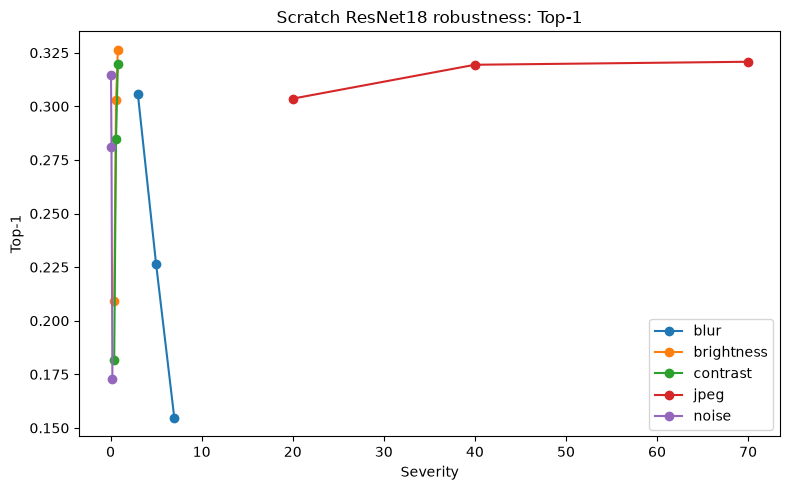

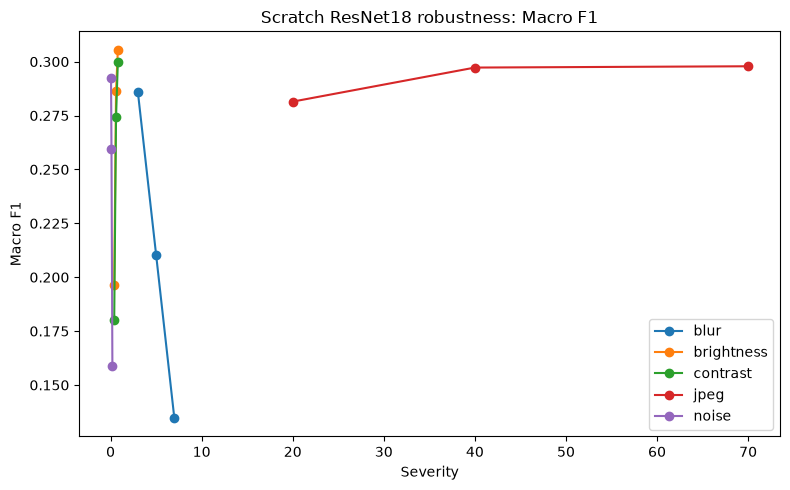

In [22]:
if not robustness_results.empty:
    for metric in ("Top-1", "Macro F1"):
        plt.figure(figsize=(8, 5))

        for degradation, group in robustness_results.groupby("Degradation"):
            ordered = group.sort_values("Severity")
            plt.plot(
                ordered["Severity"],
                ordered[metric],
                marker="o",
                label=degradation,
            )

        plt.xlabel("Severity")
        plt.ylabel(metric)
        plt.title(f"Scratch ResNet18 robustness: {metric}")
        plt.legend()
        plt.tight_layout()
        plt.show()

## 12. Experimental findings

- Without augmentation, the model reached nearly perfect training accuracy but substantially lower validation accuracy, indicating severe overfitting.
- Data augmentation improved validation Top-1 accuracy from **21.54%** to **31.94%** and validation Macro F1 from **21.42%** to **30.06%**.
- The selected model achieved **32.10% Top-1**, **57.66% Top-5**, and **29.73% Macro F1** on the held-out test set.
- Gaussian blur produced the largest degradation, while JPEG compression had the smallest effect.